In [1]:
!pip install hazm


# phase 1

In [13]:
import pandas as pd
from hazm import Normalizer, word_tokenize
import re


df = pd.read_csv('books_train.csv')
normalizer = Normalizer()
df.iloc[:30]

,title,description,categories
0,ساختار نظریه‌های جامعه‌شناسی ایران,«ساختار نظریه‌های جامعه‌شناسی ایران» نوشته ابو...,جامعه‌شناسی
1,جامعه و فرهنگ کانادا,«جامعه و فرهنگ کانادا» از مجموعه کتاب‌های «جام...,جامعه‌شناسی
2,پرسش از موعود,پرسش‌های مختلفی درباره زندگی و شخصیت امام مهدی...,کلیات اسلام
3,موج، دریا,«موج دریا» به قلم مهری ماهوتی (-۱۳۴۰) و تصویرگ...,داستان کودک و نوجوانان
4,پرسش از غرب,«پرسش از غرب» به قلم دکتر اسماعیل شفیعی سروستا...,جامعه‌شناسی
5,خارج از خط,«خارج از خط» مجموعه داستان کوتاهی نوشته محمود ...,داستان کوتاه
6,لاک صورتی,«لاک صورتی» نوشته جلال آل احمد(۱۳۴۸-۱۳۰۲) نویس...,داستان کوتاه
7,راهبردهای سرمایه گذاری کسب و کار,راه‌های بسیار زیادی برای سرمایه‌گذاری در دنیا ...,مدیریت و کسب و کار
8,تحلیل گفتمان و نظرات رسانه‌های بریتانیا: چهره‌...,با شکل‌گیری و رشد روز افزون دهکده جهانی، بشر ب...,کلیات اسلام
9,رویکردی جدید به اختلالات مصرف مواد و مشاوره‌ی ...,«رویکردی جدید به اختلالات مصرف مواد و مشاوره‌ی...,جامعه‌شناسی


In [14]:

def preprocess_text(text):
    text = normalizer.normalize(text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    tokens = word_tokenize(text)
    text = ' '.join(tokens)
    return text


df['description'] = df['description'].apply(preprocess_text)
df.to_csv('books_train_preprocessed.csv', index=False)


In [15]:
df.iloc[:30]

,title,description,categories
0,ساختار نظریه‌های جامعه‌شناسی ایران,ساختار نظریههای جامعهشناسی ایران نوشته ابوالفض...,جامعه‌شناسی
1,جامعه و فرهنگ کانادا,جامعه و فرهنگ کانادا از مجموعه کتابهای جامعه و...,جامعه‌شناسی
2,پرسش از موعود,پرسشهای مختلفی درباره زندگی و شخصیت امام مهدی ...,کلیات اسلام
3,موج، دریا,موج دریا به قلم مهری ماهوتی و تصویرگری عاطفه م...,داستان کودک و نوجوانان
4,پرسش از غرب,پرسش از غرب به قلم دکتر اسماعیل شفیعی سروستانی...,جامعه‌شناسی
5,خارج از خط,خارج از خط مجموعه داستان کوتاهی نوشته محمود را...,داستان کوتاه
6,لاک صورتی,لاک صورتی نوشته جلال آل احمد نویسنده و فعال اج...,داستان کوتاه
7,راهبردهای سرمایه گذاری کسب و کار,راههای بسیار زیادی برای سرمایهگذاری در دنیا وج...,مدیریت و کسب و کار
8,تحلیل گفتمان و نظرات رسانه‌های بریتانیا: چهره‌...,با شکلگیری و رشد روز افزون دهکده جهانی بشر بیش...,کلیات اسلام
9,رویکردی جدید به اختلالات مصرف مواد و مشاوره‌ی ...,رویکردی جدید به اختلالات مصرف مواد و مشاورهی ا...,جامعه‌شناسی


# phase 2

In [16]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
df = pd.read_csv('books_train_preprocessed.csv')
X = df['description']
y = df['categories']

vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_bow, y, test_size=0.2, random_state=42)


In [17]:
model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.7411764705882353


In [18]:
df_test = pd.read_csv('books_test.csv')
X_new = vectorizer.transform(df_test['description'].apply(preprocess_text))
predictions = model.predict(X_new)

df_test['predicted_category'] = predictions
df_test.to_csv('books_test_with_predictions.csv', index=False)

In [8]:
df_test.iloc[:30]

,title,description,categories,predicted_category
0,کآشوب,«کآشوب (بیست و سه روایت از روضه‌هایی که زندگی ...,داستان کوتاه,رمان
1,داستان‌های برق‌آسا,«داستان‌های برق‌آسا» نام مجموعه داستان‌هایی به...,داستان کوتاه,داستان کوتاه
2,بحثی درباره مرجعیت و روحانیت,مجموعه مقالات «بحثی درباره مرجعیت و روحانیت» ش...,کلیات اسلام,کلیات اسلام
3,قلعه‌ی حیوانات,«قلعه‌ی حیوانات» جورج اورول، درباره گروهی از ح...,رمان,رمان
4,قصه ما مثل شد (۱),«قصه ما مثل شد» یک مجموعه کتاب ۵ جلدی است که د...,داستان کودک و نوجوانان,داستان کودک و نوجوانان
5,اسلام و چالش اقتصادی,«اسلام و چالش اقتصادی» نوشته محمد عمر چپرا( ...,کلیات اسلام,جامعه‌شناسی
6,مواعظ (جلد ۳),«مواعظ» دربردارنده سلسله مباحث اخلاقی آیت‌الله...,کلیات اسلام,کلیات اسلام
7,ماندن (مجموعه‌ داستان پیوسته),«ماندن» مجموعه‌ داستان‌هایی پیوسته از مرتضی فر...,داستان کوتاه,رمان
8,چرا اقتصاد فرو می‌ریزد؟: به سوی نظریه‌ای عمومی...,«جوزف استیگلیتز» برنده جایزه نوبل اقتصاد در سا...,جامعه‌شناسی,جامعه‌شناسی
9,تطهیر با جاری قرآن؛ تفسیر جلد سی‌ام (جلد اول),مجموعه سی و یک جلدی «تطهیر جاری با قرآن» شامل ...,کلیات اسلام,کلیات اسلام


# phase 3


part1:

In [52]:
import pandas as pd
from hazm import Stemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
df_train = pd.read_csv('books_train_preprocessed.csv')
stemmer=Stemmer()

def stem_text(text):
    return ' '.join([stemmer.stem(word) for word in text.split()])


df_train['description_stemmed'] = df_train['description'].apply(stem_text)


df_train.iloc[:30]

,title,description,categories,description_stemmed
0,ساختار نظریه‌های جامعه‌شناسی ایران,ساختار نظریههای جامعهشناسی ایران نوشته ابوالفض...,جامعه‌شناسی,ساختار نظریه جامعهشناس ایر نوشته ابوالفضل رمضا...
1,جامعه و فرهنگ کانادا,جامعه و فرهنگ کانادا از مجموعه کتابهای جامعه و...,جامعه‌شناسی,جامعه و فرهنگ کانادا از مجموعه کتاب جامعه و فر...
2,پرسش از موعود,پرسشهای مختلفی درباره زندگی و شخصیت امام مهدی ...,کلیات اسلام,پرسش مختلف درباره زندگ و شخص اما مهد عج در اذه...
3,موج، دریا,موج دریا به قلم مهری ماهوتی و تصویرگری عاطفه م...,داستان کودک و نوجوانان,موج دریا به قل مهر ماهوت و تصویرگر عاطفه ملکیج...
4,پرسش از غرب,پرسش از غرب به قلم دکتر اسماعیل شفیعی سروستانی...,جامعه‌شناسی,پرس از غرب به قل دک اسماعیل شفیع سروستان به نو...
5,خارج از خط,خارج از خط مجموعه داستان کوتاهی نوشته محمود را...,داستان کوتاه,خارج از خط مجموعه داس کوتاه نوشته محمود راج نو...
6,لاک صورتی,لاک صورتی نوشته جلال آل احمد نویسنده و فعال اج...,داستان کوتاه,لاک صورت نوشته جلال آل احمد نویسنده و فعال اجت...
7,راهبردهای سرمایه گذاری کسب و کار,راههای بسیار زیادی برای سرمایهگذاری در دنیا وج...,مدیریت و کسب و کار,راه بسیار زیاد برا سرمایهگذار در دنیا وجود دار...
8,تحلیل گفتمان و نظرات رسانه‌های بریتانیا: چهره‌...,با شکلگیری و رشد روز افزون دهکده جهانی بشر بیش...,کلیات اسلام,با شکلگیر و رشد روز افزون دهکده جهان بشر ب از ...
9,رویکردی جدید به اختلالات مصرف مواد و مشاوره‌ی ...,رویکردی جدید به اختلالات مصرف مواد و مشاورهی ا...,جامعه‌شناسی,رویکرد جدید به اختلال مصرف مواد و مشاوره اعتیا...


In [28]:
X_train = df_train['description_stemmed']
y_train = df_train['categories']
vectorizer = CountVectorizer()
X_train_bow = vectorizer.fit_transform(X_train)

In [31]:

model = MultinomialNB()
model.fit(X_train_bow, y_train)

df_test = pd.read_csv('books_test.csv')


df_test['description_stemmed'] = df_test['description'].apply(preprocess_text).apply(stem_text)
X_test_bow = vectorizer.transform(df_test['description_stemmed'])
predictions = model.predict(X_test_bow)
accuracy = accuracy_score(y_train, model.predict(X_train_bow))
print(accuracy)


0.9450980392156862


part2:

In [33]:
from hazm import stopwords_list

stopwords = set(stopwords_list())


def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word not in stopwords])



df_train['description_no_stopwords'] = df_train['description_stemmed'].apply(remove_stopwords)

X_train = df_train['description_no_stopwords']
X_train_bow = vectorizer.fit_transform(X_train)
model.fit(X_train_bow, y_train)
y_pred = model.predict(X_train_bow)
accuracy = accuracy_score(y_train, y_pred)
print(accuracy)


0.9603921568627451


part3:

In [35]:

df_train['description_combined'] = df_train['description'].apply(stem_text).apply(remove_stopwords)


X_train = df_train['description_combined']
X_train_bow = vectorizer.fit_transform(X_train)
model.fit(X_train_bow, y_train)
accuracy = accuracy_score(y_train, model.predict(X_train_bow))
print(accuracy)


0.9603921568627451


part4:

In [40]:
!pip install arabic-reshaper
!pip install python-bidi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.3/281.3 kB 2.0 MB/s eta 0:00:00


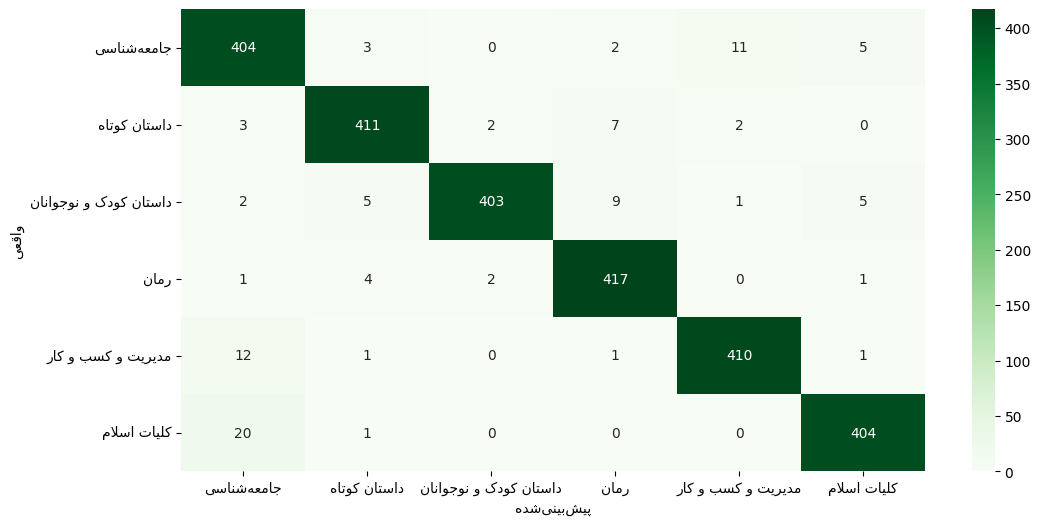

In [49]:
import arabic_reshaper
from bidi.algorithm import get_display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


def fix_text(text):
    reshaped_text = arabic_reshaper.reshape(text)
    return get_display(reshaped_text)


cm = confusion_matrix(y_train, y_pred)


labels = [fix_text(label) for label in model.classes_]

plt.figure(figsize=(12, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels)
plt.xlabel(fix_text('پیش‌بینی‌شده'))
plt.ylabel(fix_text('واقعی'))
plt.show()
